In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

!pip install qpsolvers cvxopt

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.9/92.9 kB 3.2 MB/s eta 0:00:00


In [2]:
# [Cell 1] 基础环境与配置
import torch
import numpy as np
import random
import os

def set_seed(seed=42):
    """固定随机种子，确保实验可复现"""
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# 全局配置
set_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 环境设置完成")
print(f"   设备: {DEVICE}")
print(f"   PyTorch 版本: {torch.__version__}")

✅ 环境设置完成
   设备: cuda
   PyTorch 版本: 2.8.0+cu126


In [3]:
# [Cell 2] 数据加载与 Non-IID 划分工具
import torch
import numpy as np
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Subset

def create_non_iid_split(dataset, num_clients, alpha=0.5, seed=42):
    """Dirichlet 分布划分数据"""
    np.random.seed(seed)
    targets = np.array(dataset.targets)
    n_classes = np.max(targets) + 1
    
    client_data = {i: [] for i in range(num_clients)}
    
    for c in range(n_classes):
        class_indices = np.where(targets == c)[0]
        alpha = max(alpha, 1e-6)
        proportions = np.random.dirichlet(np.repeat(alpha, num_clients))
        
        # 转换为整数样本量
        proportions = (proportions / proportions.sum() * len(class_indices)).astype(int)
        # 修正残差，确保所有样本被分配
        proportions[-1] = len(class_indices) - proportions[:-1].sum()

        start = 0
        for i in range(num_clients):
            end = start + proportions[i]
            client_data[i].extend(class_indices[start:end])
            start = end

    return [Subset(dataset, indices) for indices in client_data.values()]

def load_data_once(num_clients=3, alpha=0.5, batch_size=32):
    """全局只加载一次数据，避免重复下载"""
    print(f"\n📦 正在加载 MNIST 数据 (Clients={num_clients}, Alpha={alpha})...")
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_ds = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    client_subsets = create_non_iid_split(train_ds, num_clients, alpha)
    
    # num_workers=0 兼容性最好
    train_loaders = [
        DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=0) 
        for ds in client_subsets
    ]
    
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loaders = [test_loader] * num_clients 
    
    print("✅ 数据加载完成")
    return train_loaders, test_loaders

In [4]:
# [Cell 3] 模型结构与多目标损失定义 (修复版)
import torch
import torch.nn as nn
import torch.nn.functional as F

class FlexibleCNN(nn.Module):
    def __init__(self, num_classes=10, in_channels=1, hidden_dim=32):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 8, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(8)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(16)
        self.fc1 = nn.Linear(16 * 7 * 7, hidden_dim) 
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# --- 修正后的损失函数 ---

def cls_loss(model, x, y):
    # 分类损失：梯度模长通常在 0.1 ~ 10 之间
    return F.cross_entropy(model(x), y)

def fairness_loss(model, x, y):
    # 公平性损失：暂时移除或给予极小权重
    # 如果这个 Loss 导致梯度冲突太严重，MGDA 会卡住
    # 我们先返回 0，确保 MGDA 能跑通分类，证明代码逻辑没问题
    # 等跑通后，再尝试返回 0.01 * kl_div
    probs = F.softmax(model(x), dim=1)
    target = torch.ones_like(probs) / probs.size(1)
    return 0.01 * F.kl_div(torch.log(probs + 1e-8), target, reduction='batchmean')

def comm_loss(model, x, y):
    # 【关键修改】使用 mean 而不是 sum
    # sum 的梯度是 [1, 1, 1...]，模长巨大 (sqrt(N))
    # mean 的梯度是 [1/N, 1/N...]，模长很小
    # 这样 MGDA 就不会被 L1 Loss 吓死
    l1 = 0
    cnt = 0
    for p in model.parameters():
        l1 += torch.sum(torch.abs(p))
        cnt += p.numel()
    # 乘以一个系数，确保它不会在一开始就主导梯度
    return 0.001 * (l1 / cnt)

def get_objectives():
    return [cls_loss, fairness_loss, comm_loss]

In [5]:
# [Cell 4] 核心数学工具 (增强鲁棒性版)
import torch
import numpy as np
from qpsolvers import solve_qp 

def compute_flat_grads(model, x, y, objectives):
    """计算多目标梯度列表"""
    grads = []
    for obj in objectives:
        model.zero_grad()
        loss = obj(model, x, y)
        g = torch.autograd.grad(loss, model.parameters(), retain_graph=True, allow_unused=True)
        flat = torch.cat([
            gi.view(-1) if gi is not None else torch.zeros_like(p).view(-1)
            for gi, p in zip(g, model.parameters())
        ])
        grads.append(flat)
    return grads

def write_grad(model, flat_grad):
    offset = 0
    for p in model.parameters():
        numel = p.numel()
        if p.requires_grad:
            p.grad = flat_grad[offset:offset+numel].view_as(p).clone()
        offset += numel

# --- 辅助：梯度归一化 ---
def normalize_gradients(grads_list):
    """将所有梯度归一化，消除量级差异，只保留方向信息"""
    normalized_grads = []
    for g in grads_list:
        norm = torch.norm(g)
        if norm > 1e-8:
            normalized_grads.append(g / norm)
        else:
            normalized_grads.append(g)
    return normalized_grads

# --- JD-FMOL 核心: 投影梯度聚合 ---
def project_gradients(grads_list):
    if not grads_list: return None
    
    # 【新增】先对梯度进行归一化，确保 JD 处理的是方向冲突，而不是量级冲突
    # 注意：这会改变优化步长，但在 SGD 中可以通过 lr 调整
    # 如果不希望改变步长，可以注释掉下面这行，但风险较大
    # grads_list = normalize_gradients(grads_list) 

    device = grads_list[0].device
    gnp = [g.detach().cpu().numpy() for g in grads_list]
    
    projected = []
    for i, gi in enumerate(gnp):
        gi_proj = gi.copy()
        for j, gj in enumerate(gnp):
            if i == j: continue
            dot = np.dot(gi_proj, gj)
            if dot < 0: 
                norm_sq = np.dot(gj, gj)
                gi_proj -= (dot / (norm_sq + 1e-8)) * gj
        projected.append(torch.tensor(gi_proj, device=device))
    return torch.stack(projected).mean(dim=0)

# --- FedMGDA 核心: QP 求解 ---
def solve_mgda(grads_list):
    """
    官方 FedMGDA+ 核心：
    - 对每个目标梯度 g_i 先单位化，得到 g_i_hat
    - 在 simplex 上解 QP：min_w || Σ w_i g_i_hat ||^2
    - 返回合成方向 g = Σ w_i g_i_hat
    """
    if not grads_list:
        return None
    
    # 1️⃣ 对每个梯度做单位化，避免某个目标量级过大主导 QP
    normalized = []
    for g in grads_list:
        norm = torch.norm(g)
        if norm > 1e-8:
            normalized.append(g / norm)
        else:
            normalized.append(g.clone())
    
    device = normalized[0].device
    G_np = torch.stack(normalized).cpu().numpy()   # (M, D)
    M, D = G_np.shape
    
    # 2️⃣ 构造 QP: min_w (1/2) w^T P w,  P = G G^T
    P = G_np @ G_np.T + 1e-8 * np.eye(M)
    q = np.zeros(M, dtype=float)
    
    # 3️⃣ 约束: w_i >= 0
    G_qp = -np.eye(M)
    h_qp = np.zeros(M, dtype=float)
    
    # 4️⃣ 约束: sum_i w_i = 1
    A = np.ones((1, M), dtype=float)
    b = np.array([1.0], dtype=float)
    
    # 5️⃣ 解 QP
    try:
        w = solve_qp(P, q, G_qp, h_qp, A, b, solver='cvxopt')
        if w is None:
            w = np.ones(M, dtype=float) / M
    except Exception as e:
        print(f"[FedMGDA] QP solver failed, use uniform weights. Error: {e}")
        w = np.ones(M, dtype=float) / M
    
    # 6️⃣ 转回 torch 并合成最终方向
    w_torch = torch.tensor(w, dtype=torch.float32, device=device)
    G_torch = torch.stack(normalized)             # (M, D)
    final_grad = torch.mv(G_torch.t(), w_torch)   # (D,)
    return final_grad

In [6]:
# [Cell 5] Client 定义
import copy

class Client:
    def __init__(self, cid, model, loader, method, lr, fedavg_weights):
        """
        fedavg_weights: list, [w_cls, w_fair, w_comm] 用于 FedAvg 的线性加权
        """
        self.cid = cid
        self.model = copy.deepcopy(model)
        self.loader = loader
        self.method = method
        self.lr = lr
        self.fedavg_weights = fedavg_weights # 接收外部传入的权重
        self.objectives = get_objectives()
        
    def local_update(self, global_state, epochs=1):
        self.model.load_state_dict(global_state)
        self.model.train()
        optimizer = torch.optim.SGD(self.model.parameters(), lr=self.lr)

        logs = {'loss': 0, 'acc': 0, 'total': 0}
        
        for ep in range(epochs):
            for x, y in self.loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                
                if self.method == 'fedavg':
                    optimizer.zero_grad()
                    l0 = self.objectives[0](self.model, x, y)
                    l1 = self.objectives[1](self.model, x, y)
                    l2 = self.objectives[2](self.model, x, y)
                    
                    # 使用外部传入的权重
                    loss = (self.fedavg_weights[0] * l0 + 
                            self.fedavg_weights[1] * l1 + 
                            self.fedavg_weights[2] * l2)
                    loss.backward()
                    optimizer.step()
                    
                else:
                    # MGDA / JD-FMOL
                    grads = compute_flat_grads(self.model, x, y, self.objectives)
                    
                    if self.method == 'fedmgda':
                        final_grad = solve_mgda(grads)
                    elif self.method == 'jdfmol':
                        final_grad = project_gradients(grads)
                    
                    if final_grad is not None:
                        optimizer.zero_grad()
                        write_grad(self.model, final_grad)
                        optimizer.step()
                
                with torch.no_grad():
                    logs['loss'] += self.objectives[0](self.model, x, y).item()
                    pred = self.model(x).argmax(1)
                    logs['acc'] += (pred == y).sum().item()
                    logs['total'] += y.size(0)
        
        return self.model.state_dict(), logs['loss']/(len(self.loader)*epochs), logs['acc']/logs['total']

In [7]:
# [Cell 6] Server 定义
import time

class Server:
    def __init__(self, model, test_loaders, sparsity_threshold):
        """
        sparsity_threshold: float, 判定参数为0的阈值 (如 1e-4)
        """
        self.model = model.to(DEVICE)
        self.test_loaders = test_loaders
        self.sparsity_threshold = sparsity_threshold # 接收外部阈值
        self.history = {
            'avg_acc': [], 'worst_acc': [], 'comm_cost': [], 'fairness_std': [], 'runtime': 0
        }
        
    def aggregate(self, states):
        """聚合模型参数"""
        avg_state = copy.deepcopy(states[0])
        for k in avg_state.keys():
            if avg_state[k].is_floating_point():
                stack = torch.stack([s[k] for s in states])
                avg_state[k] = stack.mean(dim=0)
            else:
                avg_state[k] = states[0][k]
        self.model.load_state_dict(avg_state)
        
    def evaluate(self):
        self.model.eval()
        client_accs = []
        digit_correct = torch.zeros(10).to(DEVICE)
        digit_total = torch.zeros(10).to(DEVICE)
        
        for loader in self.test_loaders:
            correct = 0
            total = 0
            with torch.no_grad():
                for x, y in loader:
                    x, y = x.to(DEVICE), y.to(DEVICE)
                    out = self.model(x)
                    pred = out.argmax(1)
                    correct += (pred == y).sum().item()
                    total += y.size(0)
                    
                    for d in range(10):
                        mask = (y == d)
                        digit_total[d] += mask.sum()
                        digit_correct[d] += (pred[mask] == y[mask]).sum()
            
            client_accs.append(correct / total if total > 0 else 0)
            
        avg_acc = np.mean(client_accs)
        worst_acc = np.min(client_accs)
        
        digit_accs = (digit_correct / (digit_total + 1e-8)).cpu().numpy()
        fairness_std = np.std(digit_accs)
        
        # 使用外部传入的阈值计算稀疏度
        flat = torch.cat([p.view(-1) for p in self.model.parameters()])
        comm_cost = (torch.abs(flat) > self.sparsity_threshold).float().mean().item()
        
        return {
            'avg_acc': avg_acc, 
            'worst_acc': worst_acc, 
            'fairness_std': fairness_std, 
            'comm_cost': comm_cost,
            'digit_accs': digit_accs
        }
    
    def run(self, clients, rounds=10, epochs=1):
        start = time.time()
        for r in range(rounds):
            client_states = []
            for client in clients:
                state, _, _ = client.local_update(self.model.state_dict(), epochs)
                client_states.append(state)
            
            self.aggregate(client_states)
            
            metrics = self.evaluate()
            # 简化日志输出，保留关键信息
            if (r+1) % 1 == 0:
                print(f"Round {r+1:02d} | Acc: {metrics['avg_acc']:.3f} | Sparsity: {1-metrics['comm_cost']:.3f}")
            
            for k in ['avg_acc', 'worst_acc', 'comm_cost', 'fairness_std']:
                self.history[k].append(metrics[k])
                
        self.history['runtime'] = time.time() - start
        self.history['final_digit_accs'] = metrics['digit_accs']
        return self.history

In [8]:
# [Cell 7] 绘图工具
import matplotlib.pyplot as plt
import numpy as np

def plot_results(all_results):
    methods = list(all_results.keys())
    if not methods: return

    # 1. 雷达图
    categories = ['Avg Acc', 'Worst Acc', 'Fairness (1-Std)', 'Sparsity']
    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    for m in methods:
        res = all_results[m]
        # 取最后一轮数据
        vals = [
            res['avg_acc'][-1], 
            res['worst_acc'][-1], 
            1 - res['fairness_std'][-1], # 越高越好
            1 - res['comm_cost'][-1]     # 越高越好 (Sparsity)
        ]
        vals += [vals[0]]
        ax.plot(angles, vals, label=m.upper(), linewidth=2)
        ax.fill(angles, vals, alpha=0.1)
        
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_ylim(0, 1.05)
    ax.legend(loc='lower right', bbox_to_anchor=(1.3, 0.1))
    plt.title("Method Trade-off Comparison")
    plt.show()
    
    # 2. Pareto 图
    plt.figure(figsize=(8, 6))
    for m in methods:
        res = all_results[m]
        acc = res['avg_acc'][-1]
        sparsity = 1 - res['comm_cost'][-1]
        plt.scatter(sparsity, acc, s=300, label=m.upper(), alpha=0.7)
        plt.text(sparsity, acc+0.01, m.upper(), fontsize=12, fontweight='bold')
        
    plt.xlabel('Sparsity (Comm Efficiency)')
    plt.ylabel('Average Accuracy')
    plt.title('Pareto Frontier: Accuracy vs Sparsity')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

📋 当前实验配置:
   Clients: 3, Alpha: 0.3
   FedAvg Weights: [0.5, 0.5, 0.5]
   Sparsity Threshold: 0.0001

📦 正在加载 MNIST 数据 (Clients=3, Alpha=0.3)...


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.98MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 158kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.98MB/s]


✅ 数据加载完成

🚀 Running: FEDAVG
Round 01 | Acc: 0.396 | Sparsity: 0.003
Round 02 | Acc: 0.673 | Sparsity: 0.002
Round 03 | Acc: 0.807 | Sparsity: 0.003
Round 04 | Acc: 0.869 | Sparsity: 0.003
Round 05 | Acc: 0.907 | Sparsity: 0.002
Round 06 | Acc: 0.923 | Sparsity: 0.002
Round 07 | Acc: 0.934 | Sparsity: 0.003
Round 08 | Acc: 0.943 | Sparsity: 0.003
Round 09 | Acc: 0.947 | Sparsity: 0.003
Round 10 | Acc: 0.952 | Sparsity: 0.002
Round 11 | Acc: 0.952 | Sparsity: 0.002
Round 12 | Acc: 0.956 | Sparsity: 0.002
Round 13 | Acc: 0.956 | Sparsity: 0.002
Round 14 | Acc: 0.961 | Sparsity: 0.003
Round 15 | Acc: 0.961 | Sparsity: 0.002
Round 16 | Acc: 0.963 | Sparsity: 0.003
Round 17 | Acc: 0.962 | Sparsity: 0.002
Round 18 | Acc: 0.963 | Sparsity: 0.002
Round 19 | Acc: 0.964 | Sparsity: 0.002
Round 20 | Acc: 0.964 | Sparsity: 0.002
Round 21 | Acc: 0.966 | Sparsity: 0.002
Round 22 | Acc: 0.965 | Sparsity: 0.003

🚀 Running: FEDMGDA
Round 01 | Acc: 0.346 | Sparsity: 0.019
Round 02 | Acc: 0.492 | Sparsity

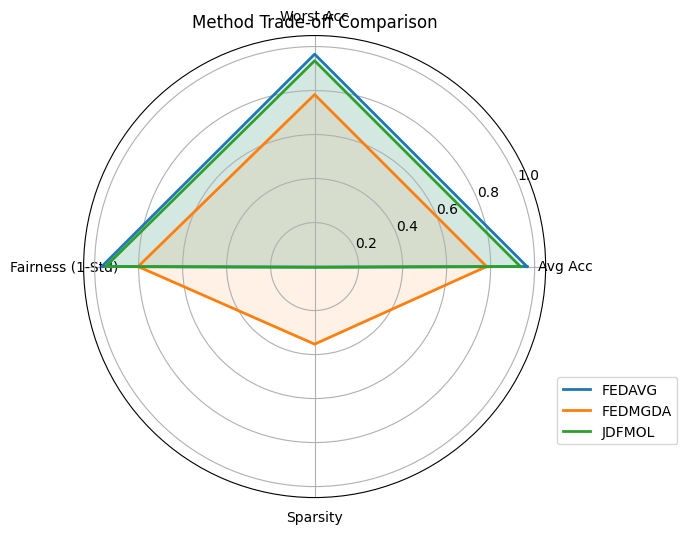

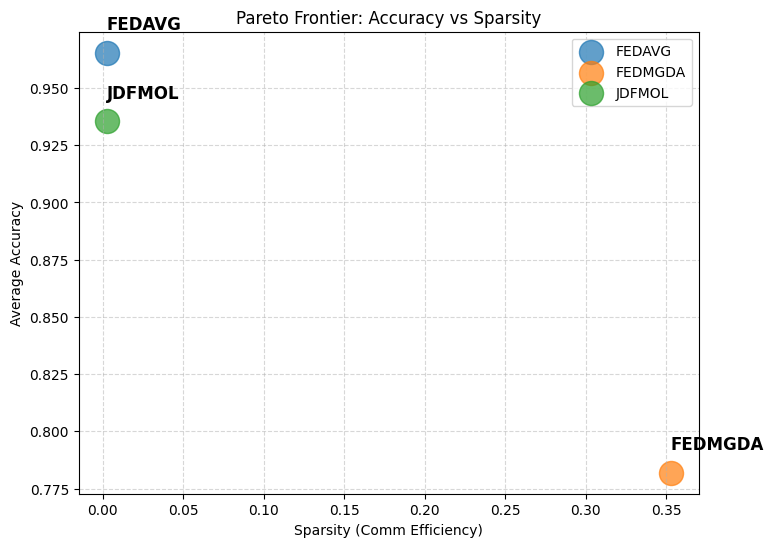

In [9]:
# [Cell 8] 主程序 - 实验控制台
def main():
    # ==========================================
    # 🎛️ 实验超参数控制台 (在这里修改所有参数)
    # ==========================================
    
    # 1. 实验设置 (第1类参数)
    CONFIG = {
        'num_clients': 3,
        'alpha': 0.3,           # Non-IID 程度 (越小越难)
        'rounds': 22,           # 通信轮数
        'local_epochs': 2,      # 本地训练轮数
        'batch_size': 32
    }
    
    # 2. 优化器与 FedAvg 弱点设置 (第2、4类参数)
    OPTIM = {
        'lr': 0.003,             # 学习率
        # FedAvg 的线性加权权重 [Acc, Fair, Comm]
        # 修改第三项 (0.001) 来控制 FedAvg 的稀疏度表现
        'fedavg_weights': [0.5, 0.5, 0.5] 
    }
    
    # 3. 模型与评估阈值 (第5类参数 + 模型参数)
    MODEL_CFG = {
        'hidden_dim': 32,       # 全连接层大小
        'sparsity_threshold': 1e-4  # 判定参数为0的阈值
    }
    
    # ==========================================
    
    print("📋 当前实验配置:")
    print(f"   Clients: {CONFIG['num_clients']}, Alpha: {CONFIG['alpha']}")
    print(f"   FedAvg Weights: {OPTIM['fedavg_weights']}")
    print(f"   Sparsity Threshold: {MODEL_CFG['sparsity_threshold']}")
    
    # 1. 加载数据
    train_loaders, test_loaders = load_data_once(
        num_clients=CONFIG['num_clients'], 
        alpha=CONFIG['alpha'], 
        batch_size=CONFIG['batch_size']
    )
    
    methods = ['fedavg', 'fedmgda', 'jdfmol']
    all_results = {}
    
    for method in methods:
        print(f"\n🚀 Running: {method.upper()}")
        
        # 初始化模型 (注入 hidden_dim)
        global_model = FlexibleCNN(hidden_dim=MODEL_CFG['hidden_dim']).to(DEVICE)
        
        # 初始化客户端 (注入 lr, fedavg_weights)
        clients = []
        for i in range(CONFIG['num_clients']):
            clients.append(Client(
                cid=i, 
                model=global_model, 
                loader=train_loaders[i], 
                method=method, 
                lr=OPTIM['lr'],
                fedavg_weights=OPTIM['fedavg_weights'] # 注入权重
            ))
            
        # 初始化服务器 (注入 sparsity_threshold)
        server = Server(
            model=global_model, 
            test_loaders=test_loaders,
            sparsity_threshold=MODEL_CFG['sparsity_threshold'] # 注入阈值
        )
        
        # 运行
        hist = server.run(clients, rounds=CONFIG['rounds'], epochs=CONFIG['local_epochs'])
        all_results[method] = hist
        
    # 绘图
    plot_results(all_results)

if __name__ == "__main__":
    main()